# 9.5.1 把参数不确定性带入预测

## 学习目标与先修知识

推导预测的总方差（variance）并构造混合分布（distribution），区分可信区间（credible interval）和预测区间（prediction interval）。

先修：9.1的后验（posterior）积分，第5篇条件期望（expectation）与总方差，9.3的近似族。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

两种方法得到相近的参数（parameter）均值，却可能给出很不同的未来读数区间。参数样本之间的变化、观测（observation）自身的随机性以及推断计算误差，应怎样分别表达？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

两个参数情形权重为1:3，未来读数条件均值0、2 U，条件方差都为1 U²。先手算均值与两部分方差。

In [2]:
mean=.25*0+.75*2
within=1.;between=.25*(0-mean)**2+.75*(2-mean)**2
print("均值、条件方差贡献、均值变化贡献、总方差：",mean,within,between,within+between)

均值、条件方差贡献、均值变化贡献、总方差： 1.5 1.0 0.75 1.75


## 模型假设

给定参数θ与已有观测y，新读数的条件均值m(θ)、方差v(θ)已由预测模型（model）定义。后验可以表示为归一化密度或带权节点；节点权重必须包含积分微元，不能把非均匀网格当等权样本。当前读数单位为U，读数方差为U²；对数密度比较固定在同一数值单位下。

## 数学解释与推导

预测要同时平均参数后验和新读数条件分布：
$$p(y_{new}\mid y)=\int p(y_{new}\mid\theta,y)p(\theta\mid y)\,d\theta.$$
先对新读数求条件期望、再对θ平均，$E[y_{new}\mid y]=E_\theta[m(\theta)]$。将读数减去总体均值拆为“读数减条件均值”与“条件均值减总体均值”，交叉项条件期望为0，因此
$$\operatorname{Var}(y_{new}\mid y)=E_\theta[v(\theta)]+\operatorname{Var}_\theta[m(\theta)].$$
第一部分含给定参数后的观测/过程随机性，第二部分反映参数未知造成的条件均值变化。两者都不是“有限采样（sampling）次数造成的计算误差”。

带权节点的离散形式为 $\bar m=\sum_iw_im_i$，$V=\sum_iw_iv_i+\sum_iw_i(m_i-\bar m)^2$。高斯偏差共轭例得到v+r。非线性清除中，$E[e^{-kt}]$一般不等于 $e^{-E[k]t}$，所以代入平均参数也不保证正确均值。

混合高斯分布（Gaussian distribution）的CDF是 $F(y)=\sum_iw_i\Phi((y-m_i)/\sqrt{v_i})$。预测分位数可在覆盖目标概率（probability）的区间内二分求根。用均值±1.96标准差（standard deviation）只有对单高斯才近似95%；对分离混合应计算实际质量或混合分位数。参数可信区间与新观测预测区间对象不同，也不等于同时覆盖整条未来路径的区间。

## 核心实现

将刚才推导的关系逐步写成函数。

In [3]:
def predictive_moments(weights,conditional_means,conditional_variances):
    total=sum(weights);w=[x/total for x in weights]
    mean=sum(p*m for p,m in zip(w,conditional_means))
    within=sum(p*v for p,v in zip(w,conditional_variances))
    between=sum(p*(m-mean)**2 for p,m in zip(w,conditional_means))
    return mean,within+between,within,between


def normal_logpdf(value,mean,variance):
    return -.5*(math.log(2*math.pi*variance)+(value-mean)**2/variance)

## 对照实验

比较同矩高斯与分离双峰预测；同时画出参数均值代入和后验平均在非线性清除下的差异。这里的两节点后验是公开教学设定，不用于宣称真实参数分布。

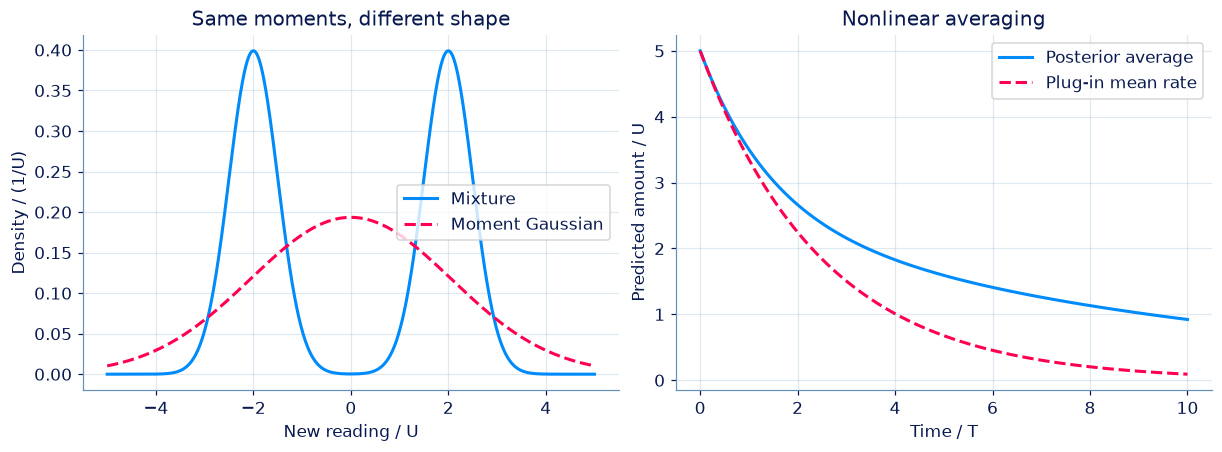

| 区间 | 下界 / U | 上界 / U | 实际预测质量 |
| --- | --- | --- | --- |
| 混合等尾 | -2.82243 | 2.82243 | 0.95 |
| 矩匹配高斯 | -4.04064 | 4.04064 | 0.999978 |

In [4]:
weights=[.5,.5];means=[-2.,2.];variances=[.25,.25];m,v,within,between=predictive_moments(weights,means,variances)
x=np.linspace(-5,5,1000);density=np.array([sum(w*math.exp(normal_logpdf(z,mu,var)) for w,mu,var in zip(weights,means,variances)) for z in x])
fig,axes=plt.subplots(1,2,figsize=(11,4));axes[0].plot(x,density,label='Mixture');axes[0].plot(x,np.exp([normal_logpdf(z,m,v) for z in x]),'--',label='Moment Gaussian');axes[0].set(xlabel='New reading / U',ylabel='Density / (1/U)',title='Same moments, different shape');axes[0].legend()
t=np.linspace(0,10,100);average=5*(.5*np.exp(-.1*t)+.5*np.exp(-.7*t));plug=5*np.exp(-.4*t)
axes[1].plot(t,average,label='Posterior average');axes[1].plot(t,plug,'--',label='Plug-in mean rate');axes[1].set(xlabel='Time / T',ylabel='Predicted amount / U',title='Nonlinear averaging');axes[1].legend();plt.show()
Phi=lambda z:(1+math.erf(z/math.sqrt(2)))/2
cdf=lambda z:sum(w*Phi((z-mu)/math.sqrt(var)) for w,mu,var in zip(weights,means,variances))
def quantile(prob):
    lo,hi=-10.,10.
    assert cdf(lo)<prob<cdf(hi)
    for _ in range(70):
        mid=(lo+hi)/2
        if cdf(mid)<prob:lo=mid
        else:hi=mid
    return (lo+hi)/2
interval=[quantile(.025),quantile(.975)];gaussian=[m-1.96*math.sqrt(v),m+1.96*math.sqrt(v)]
display(Markdown(show_table(['区间','下界 / U','上界 / U','实际预测质量'],[('混合等尾',*interval,cdf(interval[1])-cdf(interval[0])),('矩匹配高斯',*gaussian,cdf(gaussian[1])-cdf(gaussian[0]))])))

## 结果解释

两个分布可以共享均值和方差，却在中心与尾部分配不同质量。表中精确混合分位数区间达到设定的模型内质量，矩匹配高斯区间则可能更宽。这个数仍不是现实世界的长期覆盖保证；若条件噪声或机制错设，预测分布即使计算精确也会失配。右图说明先平均参数再计算响应会改变非线性预测。

### 独立核对

直接利用各分量的二阶原点矩求总方差，作为中心化公式的独立核对；以数值积分核对密度矩，并检查零权重节点。

In [5]:
second=sum(w*(var+mu*mu) for w,mu,var in zip(weights,means,variances))
np.testing.assert_allclose(v,second-m*m)
np.testing.assert_allclose([np.trapezoid(density,x),np.trapezoid(x*density,x),np.trapezoid(x*x*density,x)],[1,m,v+m*m],atol=1e-7)
assert abs(cdf(interval[1])-cdf(interval[0])-.95)<1e-12
assert predictive_moments([0,1],[100,3],[50,0])==(3,0,0,0)
np.testing.assert_allclose(predictive_moments([1,3],[0,2],[1,1]),[1.5,1.75,1,.75])
print('原点矩、积分、混合分位数与零权重边界通过。')

原点矩、积分、混合分位数与零权重边界通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/09-05-后验预测与模型检验/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：分解预测方差

将参数（parameter）后验（posterior）节点带入未来观测（observation）分布（distribution）。按全概率（probability）与总方差（variance）公式返回混合预测矩。

**函数与代码模板**

```python
def solve(
    weights: list[float],
    conditional_means: list[float],
    conditional_variances: list[float],
) -> tuple[float, float, float, float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `weights` | `list[float]` | 非负节点权重，可未归一化，但总和为正。 | 1 |
| `conditional_means` | `list[float]` | 每个参数节点的未来读数均值。 | U |
| `conditional_variances` | `list[float]` | 每节点的未来读数条件方差。 | U² |

**返回值**

按以下顺序返回元组：(mean, variance, within, between)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `mean` | `float` | 混合预测均值。 | U |
| `variance` | `float` | 总预测方差。 | U² |
| `within` | `float` | 加权条件方差。 | U² |
| `between` | `float` | 条件均值的加权方差。 | U² |

**计算规则**

先归一化w；m=sum(wi mi)，within=sum(wi vi)，between=sum(wi(mi−m)²)，variance=within+between。

**约束与边界**

- 1—100节点；权重≥0且总和>0；|mi|≤100；0≤vi≤100；三组列表等长。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| weights | 非负节点权重，可未归一化，但总和为正。 | [1.0, 3.0] | 1 |
| conditional_means | 每个参数节点的未来读数均值。 | [0.0, 2.0] | U |
| conditional_variances | 每节点的未来读数条件方差。 | [1.0, 1.0] | U² |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
weights = [1.0, 3.0]
conditional_means = [0.0, 2.0]
conditional_variances = [1.0, 1.0]

result = solve(weights, conditional_means, conditional_variances)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| mean | 混合预测均值。 | 1.5 | U |
| variance | 总预测方差。 | 1.75 | U² |
| within | 加权条件方差。 | 1 | U² |
| between | 条件均值的加权方差。 | 0.75 | U² |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (1.5, 1.75, 1.0, 0.75)
```

**样例解释**

均值1.5；条件噪声方差1，加上节点均值方差.75，得到总方差1.75。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：分解预测方差](http://127.0.0.1:8000/chapters/09-05-%E5%90%8E%E9%AA%8C%E9%A2%84%E6%B5%8B%E4%B8%8E%E6%A8%A1%E5%9E%8B%E6%A3%80%E9%AA%8C/practice/?question=p09-predictive-moments)

### 第 2 题 · 多项选择题：同样是95%区间

在给定模型（model）和数据下，参数（parameter）的95%可信区间（credible interval）和未来读数的95%预测区间（prediction interval）有何不同？

- **A.** 前者关于未知参数，后者关于新观测（observation）。
- **B.** 预测区间还包含新观测的随机性。
- **C.** 二者必须同宽。
- **D.** 可信区间宽度就是数值积分误差。

[作答：同样是95%区间](http://127.0.0.1:8000/chapters/09-05-%E5%90%8E%E9%AA%8C%E9%A2%84%E6%B5%8B%E4%B8%8E%E6%A8%A1%E5%9E%8B%E6%A3%80%E9%AA%8C/practice/?question=p09-interval-meaning)

### 第 3 题 · 多项选择题：把平均参数代入就行吗

预测均值为E[A0 exp(−kt)|y]。是否总等于A0 exp(−E[k|y]t)？

- **A.** 总相等。
- **B.** 一般不相等，因为映射非线性。
- **C.** 只能通过模拟得到，不能积分。
- **D.** 参数（parameter）后验（posterior）很窄时可近似，但须检查误差。

[作答：把平均参数代入就行吗](http://127.0.0.1:8000/chapters/09-05-%E5%90%8E%E9%AA%8C%E9%A2%84%E6%B5%8B%E4%B8%8E%E6%A8%A1%E5%9E%8B%E6%A3%80%E9%AA%8C/practice/?question=p09-nonlinear-expectation)

### 第 4 题 · 单项选择题：只有均值和方差还不够

一个预测分布（distribution）是分离的双高斯混合。用m±1.96s作为区间时，应怎样表述？

- **A.** 必为精确95%预测区间（prediction interval）。
- **B.** 它是矩匹配高斯区间，实际质量需从混合分布核对。
- **C.** 均值和方差（variance）唯一决定任意分布。
- **D.** 直接用节点均值范围就是95%区间。

[作答：只有均值和方差还不够](http://127.0.0.1:8000/chapters/09-05-%E5%90%8E%E9%AA%8C%E9%A2%84%E6%B5%8B%E4%B8%8E%E6%A8%A1%E5%9E%8B%E6%A3%80%E9%AA%8C/practice/?question=p09-mixture-not-normal)

### 第 5 题 · 多项选择题：为什么还要条件方差

只使用后验（posterior）参数（parameter）样本生成无噪声平均轨迹（trajectory），并据此给未来单次读数画带，会怎样？

- **A.** 可能漏掉观测（observation）或过程随机性。
- **B.** 样本多就自动加回观测噪声。
- **C.** 若目标本来就是无噪声平均响应，则应明确该带的对象。
- **D.** 带越窄越能证明方法好。

[作答：为什么还要条件方差](http://127.0.0.1:8000/chapters/09-05-%E5%90%8E%E9%AA%8C%E9%A2%84%E6%B5%8B%E4%B8%8E%E6%A8%A1%E5%9E%8B%E6%A3%80%E9%AA%8C/practice/?question=p09-conditional-variance)

**进一步阅读**

[Murphy，Probabilistic Machine Learning: Advanced Topics](https://probml.github.io/pml-book/book2.html)：后验近似、采样与预测检验。